# H3 Compounding vulnerability: connectivity gaps and service gaps overlap

**Claim under test.** Communities beyond the mobile-coverage gap threshold are not randomly
worse-served on other dimensions — they are systematically further from schools, medical
facilities and emergency services, and disproportionately likely to have none of the three
nearby at all.

- **H0 (null):** distance to the nearest school / medical facility / emergency service is
  independent of mobile connectivity-gap status (`distance_gap_candidate`) — the two groups'
  distance distributions are the same, and having zero services within 10 km is no more common
  in one group than the other.
- **H1 (alternative):** communities beyond the mobile-gap threshold have significantly greater
  distances to every service type, and a significantly higher rate of zero services within
  10 km.

**Data:** `village_gap_with_services.csv` (carries both the connectivity-gap flag from
`notebooks/06` and the service distances from `notebooks/11` in one table already).

**Method.** Service distances are right-skewed (a long tail of very remote communities), so a
rank-based test is appropriate rather than a t-test: two-sided **Mann-Whitney U** per service
type, with rank-biserial correlation as effect size. For the "zero services nearby" question,
a 2x2 **Fisher's exact test** (gap status) x (zero services within 10 km), with odds ratio.

**Two definitions of "connectivity gap".** The main test uses the mobile gap (`distance_gap_candidate`,
nb 06). A second pass uses `no_connectivity` from nb 11 -- no mobile, no NBN fixed footprint **and** no
RICT public phone/Wi-Fi within 2 km -- so the result is checked against every connectivity source,
not mobile alone.

**Unit of analysis.** A community is a BushTel place (reference point only; counts are places, not
people -- no population is used here). Villages in the same SA1 share geography, so a cluster
bootstrap that resamples whole SA1s checks that the result does not rely on treating them as
independent.

In [1]:
# Every import for the whole notebook lives in this cell.
%matplotlib inline
import os
from pathlib import Path

if os.path.basename(os.getcwd()) == "hypothesis_proof_notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
DATA = Path("data/processed")


In [2]:
vg = pd.read_csv(DATA / "village_gap_with_services.csv", dtype={"sa1_code": str})
assert vg["community_id"].is_unique and len(vg) == 792

gap = vg[vg["distance_gap_candidate"] == True]
notgap = vg[vg["distance_gap_candidate"] == False]
print(f"beyond mobile-gap threshold: {len(gap)}")
print(f"within mobile-gap threshold: {len(notgap)}")

SERVICES = [("km_nearest_school", "school"), ("km_nearest_medical", "medical"), ("km_nearest_emergency", "emergency")]
desc = pd.DataFrame({
    label: {
        "gap median (km)": gap[col].median(), "gap IQR": gap[col].quantile(.75) - gap[col].quantile(.25),
        "non-gap median (km)": notgap[col].median(), "non-gap IQR": notgap[col].quantile(.75) - notgap[col].quantile(.25),
    } for col, label in SERVICES
}).T
desc.round(1)

beyond mobile-gap threshold: 384
within mobile-gap threshold: 408


,gap median (km),gap IQR,non-gap median (km),non-gap IQR
school,38.2,35.6,7.3,14.4
medical,46.2,43.5,10.2,29.2
emergency,47.7,45.9,12.2,30.6


## Mann-Whitney U tests: is the gap group's distance distribution shifted higher?

In [3]:
results = {}
for col, label in SERVICES:
    a, b = gap[col].dropna(), notgap[col].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="greater")   # H1: gap-group distances > non-gap-group distances
    n1, n2 = len(a), len(b)
    rank_biserial = (2 * u) / (n1 * n2) - 1     # effect size -1..1: +1 = every gap distance is larger, 0 = no difference
    results[label] = (u, p, rank_biserial)
    print(f"{label:10s}  gap median={a.median():6.1f} km   non-gap median={b.median():6.1f} km   "
          f"U={u:,.0f}   p={p:.3e}   rank-biserial r={rank_biserial:.3f}")
print()
print("rank-biserial r close to 1 = almost every gap-group distance exceeds almost every",
      "non-gap-group distance (a very large, not marginal, effect).")

school      gap median=  38.2 km   non-gap median=   7.3 km   U=134,600   p=9.191e-69   rank-biserial r=0.718
medical     gap median=  46.2 km   non-gap median=  10.2 km   U=129,754   p=8.823e-58   rank-biserial r=0.656
emergency   gap median=  47.7 km   non-gap median=  12.2 km   U=128,618   p=2.390e-55   rank-biserial r=0.642

rank-biserial r close to 1 = almost every gap-group distance exceeds almost every non-gap-group distance (a very large, not marginal, effect).


## Fisher's exact test: zero services within 10 km

`n_schools_10km`, `n_medical_10km`, `n_emergency_10km` are already computed by
`notebooks/11_services_gap.ipynb`. A community has "zero services nearby" if all three are 0.

In [4]:
vg["zero_services_10km"] = (
    (vg["n_schools_10km"] == 0) & (vg["n_medical_10km"] == 0) & (vg["n_emergency_10km"] == 0)
)
ct = pd.crosstab(vg["distance_gap_candidate"], vg["zero_services_10km"])
ct.index = ["within mobile-gap threshold", "beyond mobile-gap threshold"]
ct.columns = ["has >=1 service within 10km", "zero services within 10km"]
print(ct)

odds_ratio, p_fisher = stats.fisher_exact(ct)
rate_gap = vg.loc[vg["distance_gap_candidate"], "zero_services_10km"].mean()
rate_notgap = vg.loc[~vg["distance_gap_candidate"], "zero_services_10km"].mean()
print()
print(f"rate of 'zero services within 10km': {rate_gap:.1%} (beyond gap) vs {rate_notgap:.1%} (within gap)")
print(f"Fisher's exact test: odds ratio={odds_ratio:.1f}   p={p_fisher:.3e}")

                             has >=1 service within 10km  zero services within 10km
within mobile-gap threshold                          249                        159
beyond mobile-gap threshold                            9                        375

rate of 'zero services within 10km': 97.7% (beyond gap) vs 39.0% (within gap)
Fisher's exact test: odds ratio=65.3   p=1.608e-81


## Second definition: `no_connectivity` (mobile + fixed + public access all missing)

Same two tests, with the gap group redefined as villages that have **no** connectivity path in the data:
no mobile tower (nb 06 rule), outside both NBN fixed footprints, and no RICT site within 2 km.


In [5]:
no_conn = vg["no_connectivity"].astype(str).str.strip().str.lower().eq("true")
nc_gap, nc_not = vg[no_conn], vg[~no_conn]
print(f"no_connectivity: {len(nc_gap)}   has some connectivity: {len(nc_not)}")
results_nc = {}
for col, label in SERVICES:
    u, p = stats.mannwhitneyu(nc_gap[col], nc_not[col], alternative="greater")
    r = (2 * u) / (len(nc_gap) * len(nc_not)) - 1
    results_nc[label] = (u, p, r)
    print(f"{label:10s}  no-conn median={nc_gap[col].median():6.1f} km   other median={nc_not[col].median():6.1f} km   "
          f"p={p:.3e}   rank-biserial r={r:.3f}")
ct_nc = pd.crosstab(no_conn, vg["zero_services_10km"])
odds_nc, p_fisher_nc = stats.fisher_exact(ct_nc)
rate_nc, rate_nc_not = vg.loc[no_conn, "zero_services_10km"].mean(), vg.loc[~no_conn, "zero_services_10km"].mean()
print(f"\nzero services within 10 km: {rate_nc:.1%} (no connectivity) vs {rate_nc_not:.1%} (some connectivity)")
print(f"Fisher's exact test: odds ratio={odds_nc:.1f}   p={p_fisher_nc:.3e}")


no_connectivity: 269   has some connectivity: 523
school      no-conn median=  40.2 km   other median=  11.3 km   p=3.191e-48   rank-biserial r=0.630
medical     no-conn median=  47.0 km   other median=  15.1 km   p=6.752e-38   rank-biserial r=0.555
emergency   no-conn median=  48.7 km   other median=  19.7 km   p=3.470e-36   rank-biserial r=0.542

zero services within 10 km: 98.9% (no connectivity) vs 51.2% (some connectivity)
Fisher's exact test: odds ratio=84.4   p=8.898e-54


## Robustness: resample whole SA1s, not single villages

10,000 cluster-bootstrap resamples of SA1s (every village in a drawn SA1 comes along). For each service,
the 95% interval of *gap median minus non-gap median*; for zero-services, the 95% interval of the rate
difference. If no interval crosses 0, the overlap does not depend on the independence assumption.


In [6]:
rng = np.random.default_rng(42)      # fixed seed: reproducible, not cherry-picked
N_BOOT = 10_000
is_gap = vg["distance_gap_candidate"].astype(str).str.lower().eq("true").to_numpy()
zero = vg["zero_services_10km"].to_numpy()
dist = {label: vg[col].to_numpy() for col, label in SERVICES}
groups = [np.flatnonzero(vg["sa1_code"].to_numpy() == c) for c in vg["sa1_code"].unique()]
boot = {label: np.empty(N_BOOT) for _, label in SERVICES} | {"zero_rate": np.empty(N_BOOT)}
for b in range(N_BOOT):
    idx = np.concatenate([groups[i] for i in rng.integers(0, len(groups), len(groups))])
    g, z = is_gap[idx], zero[idx]
    for _, label in SERVICES:
        d = dist[label][idx]
        boot[label][b] = np.median(d[g]) - np.median(d[~g])
    boot["zero_rate"][b] = z[g].mean() - z[~g].mean()
boot_ci = {key: np.percentile(v, [2.5, 97.5]) for key, v in boot.items()}
for key, (lo, hi) in boot_ci.items():
    unit = "pp" if key == "zero_rate" else "km"
    scale = 100 if key == "zero_rate" else 1
    print(f"{key:10s} gap - non-gap: 95% CI [{lo*scale:6.1f}, {hi*scale:6.1f}] {unit}   "
          f"{'excludes 0' if lo > 0 else 'CROSSES 0'}")
boot_ok = all(lo > 0 for lo, _ in boot_ci.values())


school     gap - non-gap: 95% CI [  24.6,   38.3] km   excludes 0
medical    gap - non-gap: 95% CI [  28.8,   45.9] km   excludes 0
emergency  gap - non-gap: 95% CI [  23.7,   49.9] km   excludes 0
zero_rate  gap - non-gap: 95% CI [  49.1,   69.3] pp   excludes 0


## Visualisation

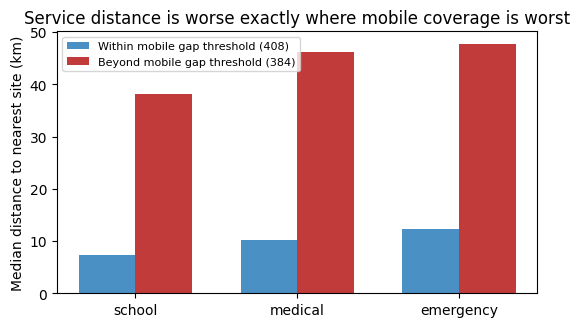

In [7]:
labels = [l for _, l in SERVICES]
gap_med = [gap[c].median() for c, _ in SERVICES]
notgap_med = [notgap[c].median() for c, _ in SERVICES]
x = np.arange(len(labels)); w = 0.35

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.bar(x - w/2, notgap_med, w, label=f"Within mobile gap threshold ({len(notgap)})", color="#4A90C4")
ax.bar(x + w/2, gap_med, w, label=f"Beyond mobile gap threshold ({len(gap)})", color="#C23B3B")
ax.set_xticks(x, labels)
ax.set_ylabel("Median distance to nearest site (km)")
ax.set_title("Service distance is worse exactly where mobile coverage is worst")
ax.legend(fontsize=8)
plt.show()

## Conclusion

In [8]:
print("H3 SUMMARY")
print("=" * 60)
print("Mobile gap (distance_gap_candidate):")
for col, label in SERVICES:
    u, p, r = results[label]
    print(f"- {label}: Mann-Whitney p={p:.2e}, rank-biserial r={r:.2f}  "
          f"({'REJECT H0' if p < 0.05 else 'fail to reject H0'})")
print(f"- zero-services-within-10km rate: {rate_gap:.0%} (beyond gap) vs {rate_notgap:.0%} (within gap)")
print(f"  Fisher's exact test: OR={odds_ratio:.1f}, p={p_fisher:.2e}  "
      f"({'REJECT H0' if p_fisher < 0.05 else 'fail to reject H0'})")
print(f"- SA1-cluster bootstrap: every 95% interval {'excludes 0' if boot_ok else 'does NOT all exclude 0'}")
print("No connectivity at all (mobile + fixed + public access missing):")
for col, label in SERVICES:
    u, p, r = results_nc[label]
    print(f"- {label}: Mann-Whitney p={p:.2e}, rank-biserial r={r:.2f}")
print(f"- zero-services rate {rate_nc:.0%} vs {rate_nc_not:.0%}; Fisher OR={odds_nc:.1f}, p={p_fisher_nc:.2e}")
print()
all_reject = (all(p < 0.05 for _, p, _ in results.values()) and p_fisher < 0.05 and boot_ok
              and all(p < 0.05 for _, p, _ in results_nc.values()) and p_fisher_nc < 0.05)
print("=> H3 is SUPPORTED" if all_reject else "=> H3 is NOT fully supported")
print("   A connectivity gap in the NT -- mobile alone, or no connectivity path at all -- is strongly")
print("   associated with being far from schools, clinics and emergency services, not an independent risk.")
print("   Counts are BushTel places, not people.")


H3 SUMMARY
Mobile gap (distance_gap_candidate):
- school: Mann-Whitney p=9.19e-69, rank-biserial r=0.72  (REJECT H0)
- medical: Mann-Whitney p=8.82e-58, rank-biserial r=0.66  (REJECT H0)
- emergency: Mann-Whitney p=2.39e-55, rank-biserial r=0.64  (REJECT H0)
- zero-services-within-10km rate: 98% (beyond gap) vs 39% (within gap)
  Fisher's exact test: OR=65.3, p=1.61e-81  (REJECT H0)
- SA1-cluster bootstrap: every 95% interval excludes 0
No connectivity at all (mobile + fixed + public access missing):
- school: Mann-Whitney p=3.19e-48, rank-biserial r=0.63
- medical: Mann-Whitney p=6.75e-38, rank-biserial r=0.56
- emergency: Mann-Whitney p=3.47e-36, rank-biserial r=0.54
- zero-services rate 99% vs 51%; Fisher OR=84.4, p=8.90e-54

=> H3 is SUPPORTED
   A connectivity gap in the NT -- mobile alone, or no connectivity path at all -- is strongly
   associated with being far from schools, clinics and emergency services, not an independent risk.
   Counts are BushTel places, not people.


**Ethical note.** This is a strong reason to treat connectivity investment and
service-delivery planning as linked, not siloed decisions — see the Recommendations section of
the project report. The pipeline (nb 11) records each gap as its own visible flag plus a simple
count (`gap_score`, `gap_dimensions`), not a hidden weighted score: which dimension matters more,
and how to weight them, remains a policy judgement for government and community stakeholders,
made deliberately in the open. Part of the overlap is shared remoteness (towers, schools and
clinics tend to sit in the same larger communities), so this shows co-location of gaps, not that
one gap causes another.
